In [1]:
import os
from mdagent import MDAgent

In [2]:
prompt13 = "Download the PDB for 2YXF. Tell me about its stability as found in the literature. Then, simulate it for 1 ns and plot its RMSD over time."
llm_var = "claude-3-opus-20240229"
tools = "all"
agent = MDAgent(agent_type="Structured", model=llm_var, top_k_tools=tools, use_memory=False)
print(llm_var)

claude-3-opus-20240229


In [3]:
agent.run(prompt13)

Thought: To answer this question, I will first need to download the PDB file for 2YXF. Then I will search the literature for information on its stability. Finally, I will set up and run a 1 ns simulation of the protein and plot the RMSD over time to assess its stability computationally.

Action:
```
{
  "action": "PDBFileDownloader",
  "action_input": "2YXF"
}
```

PDB file found with this ID: 2YXF
Here is my next step:

Thought: Now that I have downloaded the PDB file for 2YXF, I will search UniProt for information on the stability of this protein as reported in the literature.

Action:
```
{
  "action": "GetProteinAssociatedKeywords",
  "action_input": {
    "query": "2YXF",
    "primary_accession": ""
  }
}
```Here is my next step:

Thought: The keywords from UniProt provide some useful information about 2YXF, including that it is an immunoglobulin domain involved in immunity, contains disulfide bonds and glycosylation, and is associated with amyloidosis disease. However, I don't se

({'input': '\n    You are an expert molecular dynamics scientist, and\n    your task is to respond to the question or\n    solve the problem to the best of your ability using\n    the provided tools.\n\n    You can only respond with a single complete\n    \'Thought, Action, Action Input\' format\n    OR a single \'Final Answer\' format.\n\n    Complete format:\n    Thought: (reflect on your progress and decide what to do next)\n    Action:\n    ```\n    {\n        "action": (the action name, it should be the name of a tool),\n        "action_input": (the input string for the action)\n    }\n    \'\'\'\n\n    OR\n\n    Final Answer: (the final response to the original input\n    question, once all steps are complete)\n\n    You are required to use the tools provided,\n    using the most specific tool\n    available for each action.\n    Your final answer should contain all information\n    necessary to answer the question and its subquestions.\n    Before you finish, reflect on your pro

In [4]:
registry = agent.path_registry
print(os.path.basename(registry.ckpt_dir))
paths_and_descriptions = registry.list_path_names_and_descriptions()
print("\n".join(paths_and_descriptions.split(",")))

ckpt_52
Files found in registry: 2YXF_075553: PDB file downloaded from RSCB
 PDBFile ID: 2YXF_075553
 2YXF_075631: Cleaned File:  Removed Heterogens
 and Water Removed.  Replaced Nonstandard Residues. Added Hydrogens at pH 7.0. Missing Atoms Added and replaces nonstandard residues. 
 top_sim0_075644: Initial positions for simulation sim0_075644
 sim0_075644: Basic Simulation of Protein 2YXF_075631
 rec0_075646: Simulation trajectory for protein 2YXF_075631 and simulation sim0_075644
 rec1_075646: Simulation state log for protein 2YXF_075631 and simulation sim0_075644
 rec2_075646: Simulation pdb frames for protein 2YXF_075631 and simulation sim0_075644
 rmsd_2YXF: RMSD for 2YXF
 fig0_093026: RMSD plot for 2YXF


In [5]:
import re
import os
from IPython.display import Image
matches = re.findall(r"fig0_\d+", paths_and_descriptions)

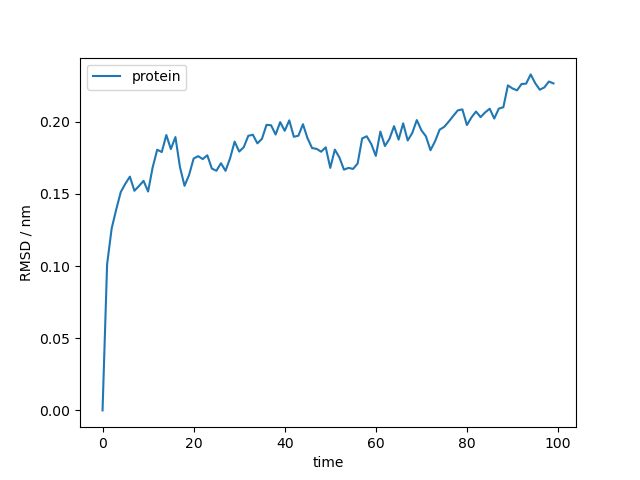

In [6]:
file_id1 = matches[0]
path1 = registry.get_mapped_path(file_id1)
assert os.path.exists(path1), "Path does not exist"
Image(filename=path1)